ej 1

In [1]:
import openeo
conn = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


ej 2 y 3
de enero a agosto 2025

In [13]:
COLLECTION = "SENTINEL2_L1C"                 
TEMPORAL_EXTENT = ["2025-01-01", "2025-08-14"]
MAX_CLOUD = 20

BANDS = ["B02", "B03", "B04", "B05", "B07", "B8A", "B08", "B11", "B12"]

# BBoxes (EPSG:4326)
lago_atitlan = {"west": -91.326256, "east": -91.07151, "south": 14.5948,   "north": 14.750979}
lago_amatitlan = {"west": -90.638065, "east": -90.512924, "south": 14.412347, "north": 14.493799}

def to_extent(box):
    return {"west": box["west"], "south": box["south"], "east": box["east"], "north": box["north"], "crs": "EPSG:4326"}

def descargar_lago(nombre, box, carpeta):
    print(f"\n🔎 {nombre}: S2 L1C {TEMPORAL_EXTENT[0]} → {TEMPORAL_EXTENT[1]} con ≤{MAX_CLOUD}% nubes, remuestreado a 10 m (EPSG:32616)…")

    cube = conn.load_collection(
        collection_id=COLLECTION,
        spatial_extent=to_extent(box),
        temporal_extent=TEMPORAL_EXTENT,
        bands=BANDS,
        max_cloud_cover=MAX_CLOUD
    )

    # remuestreo a 10 m y proyección común (UTM 16N ~ Guatemala)
    cube = cube.resample_spatial(resolution=10, projection="EPSG:32616", method="near")

    # GeoTIFF multibanda por fecha (time-slices)
    result = cube.save_result(format="GTIFF")
    job = conn.create_job(result, title=f"{nombre} S2 L1C ≤{MAX_CLOUD}% (ene-ago 2025, 10m)")
    job.start_and_wait().get_results().download_files(target=carpeta)

    print(f"✅ {nombre}: archivos guardados en './{carpeta}'")


descargar_lago("Lago Atitlán",   lago_atitlan,   "descargas_atitlan")
descargar_lago("Lago Amatitlán", lago_amatitlan, "descargas_amatitlan")


🔎 Lago Atitlán: S2 L1C 2025-01-01 → 2025-08-14 con ≤20% nubes, remuestreado a 10 m (EPSG:32616)…
0:00:00 Job 'j-250815053209400fa5e3d5c68b43e1c0': send 'start'


KeyboardInterrupt: 

ej 4

In [23]:
import os, glob, re
import numpy as np
import rasterio
from tqdm import tqdm
import pandas as pd
import scipy.ndimage as ndi  # para dilatar la máscara (1 px)

# === Entradas (de tu descarga con openEO) ===
IN_DIRS = [
    ("Lago Atitlán", "descargas_atitlan"),
    ("Lago Amatitlán", "descargas_amatitlan"),
]

# === Salida de rasters y series ===
OUT_BASE = "ciano_outputs"  # rasters procesados espejo a la estructura de entrada
TS_OUT   = "timeseries"     # CSV por lago
os.makedirs(OUT_BASE, exist_ok=True)
os.makedirs(TS_OUT, exist_ok=True)

# ---------- Utilidades numéricas ----------
def safe_div(a, b):
    with np.errstate(divide='ignore', invalid='ignore'):
        out = np.true_divide(a, b)
        out[~np.isfinite(out)] = 0.0
    return out

def open_bands(path):
    """
    Abre tif multibanda con B02,B03,B04,B05,B07,B8A,B08,B11,B12 (en ese orden).
    Normaliza a [0,1] si vienen en 0..10000 (reflectancia escalada).
    """
    names = ["B02","B03","B04","B05","B07","B8A","B08","B11","B12"]
    with rasterio.open(path) as src:
        if src.count < 9:
            raise ValueError(f"{path} necesita 9 bandas (tiene {src.count})")
        arr = {}
        for i, n in enumerate(names, 1):
            b = src.read(i).astype(np.float32)
            if np.nanpercentile(b, 99) > 1.5:  # heurística: 0..10000
                b = b / 10000.0
            b = np.clip(b, 0.0, 1.0)
            arr[n] = b
        profile = src.profile
    return arr, profile

# ---------- Máscara de nubes/sombras (solo L1C) ----------
def cloud_shadow_mask(B02, B03, B04, B08, B11, B12,
                      thr_vis=0.20, thr_swir=0.10,
                      thr_shadow_nir=0.08, thr_shadow_swir=0.04,
                      dilate_px=1):
    """
    True = ENMASCARAR (nube/sombra).
      - Nube: muy brillante en visible (B02-04) y elevada en SWIR (B11/B12).
      - Sombra: muy oscura en NIR (B08) y SWIR.
    Todas las bandas deben estar en reflectancia [0..1].
    """
    bright_vis  = (B02 > thr_vis) & (B03 > thr_vis) & (B04 > thr_vis)
    bright_swir = (B11 > thr_swir) | (B12 > thr_swir)
    cloud = bright_vis & bright_swir

    shadow = (B08 < thr_shadow_nir) & ((B11 < thr_shadow_swir) | (B12 < thr_shadow_swir))

    mask = cloud | shadow
    if dilate_px and np.any(mask):
        mask = ndi.binary_dilation(mask, iterations=dilate_px)
    return mask

# ---------- Índices del script ----------
def wbi(B04,B03,B02,B08,B11,B12, MNDWI_threshold=0.42, NDWI_threshold=0.4, filter_UABS=True):
    ndvi = safe_div((B08 - B04), (B08 + B04))
    mndwi = safe_div((B03 - B11), (B03 + B11))
    ndwi = safe_div((B03 - B08), (B03 + B08))
    ndwi_leaves = safe_div((B08 - B11), (B08 + B11))
    aweish = B02 + 2.5*B03 - 1.5*(B08 + B11) - 0.25*B12
    aweinsh = 4*(B03 - B11) - (0.25*B08 + 2.75*B11)
    dbsi = safe_div((B11 - B03), (B11 + B03)) - ndvi

    ws = np.zeros(B04.shape, dtype=np.uint8)
    cond_water = (
        (mndwi > MNDWI_threshold) |
        (ndwi  > NDWI_threshold)  |
        (aweinsh > 0.1879)        |
        (aweish  > 0.1112)        |
        (ndvi    < -0.2)          |
        (ndwi_leaves > 1)
    )
    ws[cond_water] = 1
    if filter_UABS:
        cond_urban_bare = (aweinsh <= -0.03) | (dbsi > 0)
        ws[cond_urban_bare] = 0
    return ws

def FAI(B04, B07, B8A):
    return (B07 - B04) - (B8A - B04) * ((783.0 - 665.0)/(865.0 - 665.0))

def NDCI(B04, B05):
    return safe_div((B05 - B04), (B05 + B04))

def chl_from_ndci(ndci):
    return 826.57*(ndci**3) - 176.43*(ndci**2) + 19.0*ndci + 4.071

# ---------- Paleta y render ----------
PALETTE = [
    (0.5,   (0,  0,255)),
    (1,     (0,  0,255)),
    (2.5,   (0, 59,255)),
    (3.5,   (0, 98,255)),
    (5,     (15,113,141)),
    (7,     (14,141,120)),
    (8,     (13,141,103)),
    (10,    (30,226, 28)),
    (14,    (42,226, 28)),
    (18,    (68,226, 28)),
    (20,    (68,226, 28)),
    (24,    (134,247, 0)),
    (28,    (140,247, 0)),
    (30,    (205,237, 0)),
    (38,    (208,240, 0)),
    (45,    (208,240, 0)),
    (50,    (251,210, 3)),
    (75,    (248,207, 2)),
    (90,    (134,247, 0)),
    (100,   (245,164, 9)),
    (150,   (240,159, 8)),
    (250,   (237,157, 7)),
    (300,   (239,118,15)),
    (350,   (239,101,15)),
    (450,   (239,100,14)),
    (500,   (233, 72,21)),
]
FAI_COLOR = (233, 72, 21)
FALLBACK  = (233, 72, 21)

def render_rgb(water, FAIv, chl, B04,B03,B02):
    H, W = chl.shape
    rgb = np.zeros((3, H, W), dtype=np.uint8)
    # tierra -> true color (3*B04, 3*B03, 3*B02)
    land = (water == 0)
    tc = np.stack([3*B04, 3*B03, 3*B02], axis=0)
    tc255 = np.clip(tc*255.0, 0, 255).astype(np.uint8)
    rgb[:, land] = tc255[:, land]
    # agua
    agua = (water == 1)
    # FAI primero
    fai_mask = agua & (FAIv > 0.08)
    if np.any(fai_mask):
        rgb[:, fai_mask] = np.array(FAI_COLOR, dtype=np.uint8)[:, None]
    restante = agua & (~fai_mask)
    if np.any(restante):
        assigned = np.zeros_like(restante, dtype=bool)
        for thr, col in PALETTE:
            m = restante & (~assigned) & (chl < thr)
            if np.any(m):
                rgb[:, m] = np.array(col, dtype=np.uint8)[:, None]
                assigned[m] = True
        m_fb = restante & (~assigned)
        if np.any(m_fb):
            rgb[:, m_fb] = np.array(FALLBACK, dtype=np.uint8)[:, None]
    return rgb

# ---------- Procesamiento por archivo ----------
def process_one(in_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    bands, profile = open_bands(in_path)

    B02 = bands["B02"]; B03 = bands["B03"]; B04 = bands["B04"]; B05 = bands["B05"]
    B07 = bands["B07"]; B8A = bands["B8A"]; B08 = bands["B08"]; B11 = bands["B11"]; B12 = bands["B12"]

    # 0) máscara de nubes/sombras solo con L1C
    m_cloud = cloud_shadow_mask(B02, B03, B04, B08, B11, B12,
                                thr_vis=0.20, thr_swir=0.10,
                                thr_shadow_nir=0.08, thr_shadow_swir=0.04,
                                dilate_px=1)

    # 1) máscara de agua (WBI)
    water = wbi(B04,B03,B02,B08,B11,B12).astype(bool)

    # 2) índices espectrales
    FAIv  = FAI(B04,B07,B8A)
    ndci  = NDCI(B04,B05)
    chl   = chl_from_ndci(ndci).astype(np.float32)

    # 3) máscara final: fuera de agua O nubes/sombras -> NaN
    m_nodata = (~water) | m_cloud
    chl_masked = chl.copy()
    chl_masked[m_nodata] = np.nan

    # 4) clip físico para estabilidad
    chl_masked = np.clip(chl_masked, 0.0, 500.0)

    # 5) render temático (usa water y chl_masked)
    rgb = render_rgb(water.astype(np.uint8), FAIv, chl_masked, B04,B03,B02)

    # --- Guardar salidas ---
    base = os.path.splitext(os.path.basename(in_path))[0]
    rgb_path = os.path.join(out_dir, f"{base}_cyano_rgb.tif")
    chl_path = os.path.join(out_dir, f"{base}_chl.tif")

    # RGB
    rgb_prof = profile.copy()
    rgb_prof.update({"count": 3, "dtype": "uint8", "compress": "lzw", "nodata": None})
    with rasterio.open(rgb_path, "w", **rgb_prof) as dst:
        dst.write(rgb[0], 1); dst.write(rgb[1], 2); dst.write(rgb[2], 3)

    # Chl-a (float32) con NaN fuera de agua/nubes/sombras
    chl_prof = profile.copy()
    chl_prof.update({"count": 1, "dtype": "float32", "compress": "lzw", "nodata": np.nan})
    with rasterio.open(chl_path, "w", **chl_prof) as dst:
        dst.write(chl_masked, 1)

    return rgb_path, chl_path

# ---------- Recorrer entradas y procesar ----------
def walk_and_process(in_root, out_root):
    tifs = sorted(glob.glob(os.path.join(in_root, "**", "*.tif"), recursive=True))
    if not tifs:
        print(f"⚠️ No hay .tif en {in_root}")
        return []
    out_chl_files = []
    print(f"Procesando {len(tifs)} archivos de {in_root} …")
    for tif in tqdm(tifs):
        rel = os.path.relpath(os.path.dirname(tif), in_root)
        out_dir = os.path.join(out_root, rel)
        try:
            _, chl_path = process_one(tif, out_dir)
            out_chl_files.append(chl_path)
        except Exception as e:
            print(f"❌ Error en {tif}: {e}")
    return out_chl_files

# ---------- Extraer fecha y construir series ----------
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

def extract_date_from_path(p):
    m = DATE_RE.search(p)
    return m.group(1) if m else None

def summarize_chl(chl_tif):
    with rasterio.open(chl_tif) as src:
        a = src.read(1).astype(np.float32)
    valid = np.isfinite(a)
    if not np.any(valid):
        return dict(mean=np.nan, median=np.nan, p90=np.nan, std=np.nan, water_px=0)
    vals = a[valid]
    return dict(
        mean   = float(np.nanmean(vals)),
        median = float(np.nanmedian(vals)),
        p90    = float(np.nanpercentile(vals, 90)),
        std    = float(np.nanstd(vals)),
        water_px = int(valid.sum())
    )

def build_timeseries(lake_name, out_root, csv_path):
    chl_files = sorted(glob.glob(os.path.join(out_root, "**", "*_chl.tif"), recursive=True))
    rows = []
    for f in chl_files:
        d = extract_date_from_path(f)
        if d is None:
            continue
        stats = summarize_chl(f)
        rows.append({"date": d, **stats})
    if not rows:
        print(f"⚠️ {lake_name}: no se pudieron construir series (sin fechas detectadas).")
        return
    df = pd.DataFrame(rows).sort_values("date")
    # Índice tiempo (datetime) y columnas numéricas para modelado
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df["timestamp_s"]  = (df.index.view("int64") // 10**9).astype("int64")        # seg UNIX
    df["date_ordinal"] = df.index.map(pd.Timestamp.toordinal).astype("int64")      # días enteros
    df["doy"]          = df.index.dayofyear.astype("int64")
    df["year"]         = df.index.year.astype("int64")
    df["month"]        = df.index.month.astype("int64")
    df["day"]          = df.index.day.astype("int64")
    df.to_csv(csv_path, index=True)
    print(f"🧾 Serie temporal guardada: {csv_path}")
    return df

# Ejecutar para ambos lagos: procesa y crea CSV con fecha numérica
for lake_name, in_dir in IN_DIRS:
    print(f"\n=== {lake_name} ===")
    out_dir = os.path.join(OUT_BASE, os.path.basename(in_dir))
    chl_files = walk_and_process(in_dir, out_dir)
    csv_path = os.path.join(TS_OUT, f"{os.path.basename(in_dir)}_chl_timeseries.csv")
    build_timeseries(lake_name, out_dir, csv_path)

print("\n✅ Listo. Rasters en:", OUT_BASE, " | Series en:", TS_OUT)


=== Lago Atitlán ===
Procesando 40 archivos de descargas_atitlan …


100%|██████████| 40/40 [00:35<00:00,  1.12it/s]


🧾 Serie temporal guardada: timeseries/descargas_atitlan_chl_timeseries.csv

=== Lago Amatitlán ===
Procesando 30 archivos de descargas_amatitlan …


100%|██████████| 30/30 [00:06<00:00,  4.29it/s]


🧾 Serie temporal guardada: timeseries/descargas_amatitlan_chl_timeseries.csv

✅ Listo. Rasters en: ciano_outputs  | Series en: timeseries


ej 5 y 6


=== Atitlán ===
Arrays NumPy: cube=(40, 1783, 2782), X=(40, 87774), pix_agua=87774


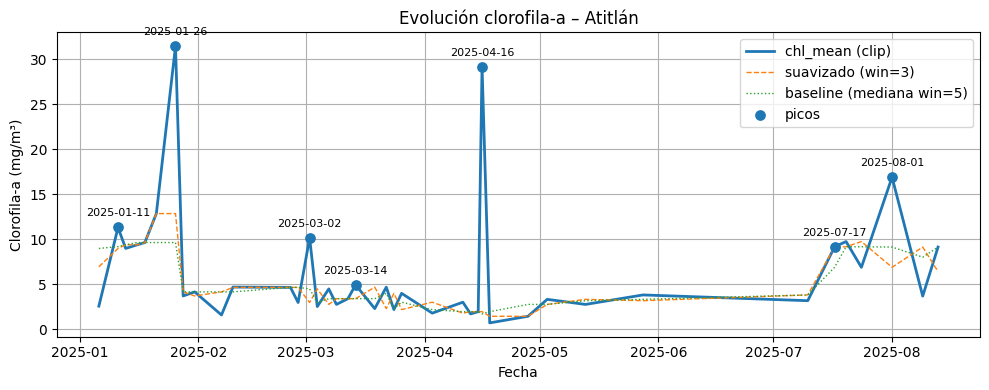

Picos detectados (7):
 • 2025-01-11  chl_mean≈11.31
 • 2025-01-26  chl_mean≈31.45
 • 2025-03-02  chl_mean≈10.16
 • 2025-03-14  chl_mean≈4.93
 • 2025-04-16  chl_mean≈29.16
 • 2025-07-17  chl_mean≈9.16
 • 2025-08-01  chl_mean≈16.90

=== Amatitlán ===
Arrays NumPy: cube=(30, 924, 1366), X=(30, 124771), pix_agua=124771


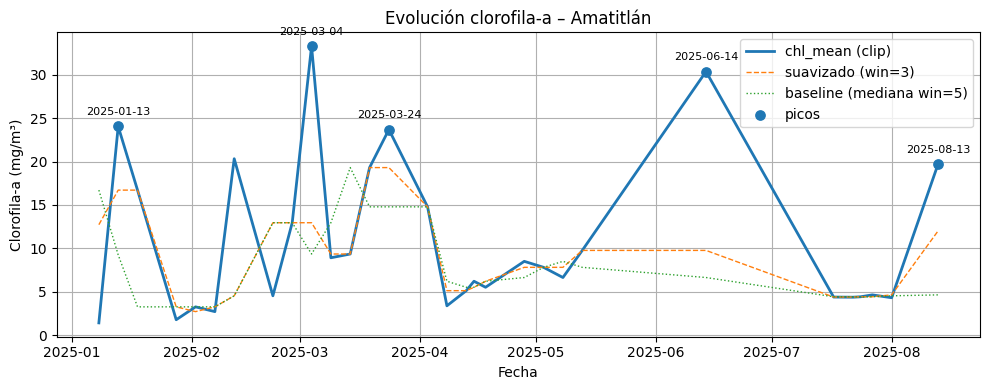

Picos detectados (5):
 • 2025-01-13  chl_mean≈24.05
 • 2025-03-04  chl_mean≈33.30
 • 2025-03-24  chl_mean≈23.69
 • 2025-06-14  chl_mean≈30.38
 • 2025-08-13  chl_mean≈19.70


In [26]:
# === PASOS 5 y 6: desde *_chl.tif a NumPy + análisis temporal (sin guardar archivos) ===
import os, glob, re
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

CYANO_OUT = "ciano_outputs"
LAKES = {
    "Atitlán":   os.path.join(CYANO_OUT, "descargas_atitlan"),
    "Amatitlán": os.path.join(CYANO_OUT, "descargas_amatitlan"),
}
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

# --- utilidades ---
def find_chl_tifs(lake_root):
    paths = sorted(glob.glob(os.path.join(lake_root, "**", "*_chl.tif"), recursive=True))
    items = []
    for p in paths:
        m = DATE_RE.search(p)
        if m:
            items.append((pd.to_datetime(m.group(1)).date(), p))
    items = sorted(items, key=lambda t: t[0])
    dates = [d.isoformat() for d,_ in items]
    paths = [p for _,p in items]
    if not paths:
        raise ValueError(f"No se encontraron *_chl.tif en {lake_root}")
    return dates, paths

def load_cube(paths):
    # asegura mismo tamaño para apilar
    with rasterio.open(paths[0]) as src0:
        H, W = src0.height, src0.width
        prof0 = (src0.transform, src0.crs)
    cube = np.full((len(paths), H, W), np.nan, dtype=np.float32)
    for i, p in enumerate(paths):
        with rasterio.open(p) as src:
            if (src.height, src.width) != (H, W):
                raise ValueError(f"Shape distinto en {p}: {(src.height,src.width)} vs {(H,W)}")
            cube[i] = src.read(1).astype(np.float32)   # ya trae NaN en tierra/nubes
    return cube, prof0

def water_mask_from_cube(cube):
    # True donde hay al menos un valor válido en el tiempo
    return np.isfinite(cube).any(axis=0)

def cube_to_matrix(cube, water_mask):
    H, W = water_mask.shape
    valid_idx = np.where(water_mask.ravel())[0]
    T = cube.shape[0]
    X = np.full((T, valid_idx.size), np.nan, dtype=np.float32)
    for t in range(T):
        X[t] = cube[t].ravel()[valid_idx]
    return X, valid_idx, (H, W)

def numeric_time(dates_iso):
    idx = pd.to_datetime(dates_iso)
    timestamp_s  = (idx.view("int64") // 10**9).astype("int64")
    date_ordinal = np.array([d.toordinal() for d in idx.to_pydatetime()], dtype="int64")
    doy          = idx.dayofyear.values.astype("int64")
    return idx, timestamp_s, date_ordinal, doy

def per_date_stats(cube):
    T = cube.shape[0]
    flat = cube.reshape(T, -1)
    return (
        np.nanmean(flat, axis=1),
        np.nanmedian(flat, axis=1),
        np.nanpercentile(flat, 90, axis=1),
        np.nanstd(flat, axis=1),
        np.sum(np.isfinite(flat), axis=1).astype(int),
    )

# --- detector de picos robusto (baseline = mediana móvil, umbral = k*MAD) ---
def robust_peaks(dates, y_clip, win=5, k_mad=2.0, min_height=10.0, distance=2):
    """
    Marca picos cuando:
      - y - mediana_móvil(win) > k_mad * MAD(residuo)  (robusto a outliers)
      - o y >= min_height (umbral absoluto)
    Además, aplica 'distance' para no marcar días adyacentes como picos distintos.
    """
    s = pd.Series(y_clip, index=dates)
    base = s.rolling(win, center=True, min_periods=1).median()
    resid = s - base
    mad = np.median(np.abs(resid.values - np.median(resid.values)))
    thr = max(k_mad * mad, 1e-6)

    cand = ((resid.values > thr) | (s.values >= min_height))
    idx = np.where(cand)[0]
    if idx.size == 0:
        return np.array([], dtype=int), base.values, resid.values, thr

    # agrupar candidatos cercanos y quedarnos con el máximo local de cada grupo
    keep = []
    start = 0
    while start < len(idx):
        group = [idx[start]]
        j = start + 1
        while j < len(idx) and (idx[j] - group[-1]) <= distance:
            group.append(idx[j])
            j += 1
        k = group[np.argmax(s.values[group])]
        keep.append(k)
        start = j

    return np.array(keep, dtype=int), base.values, resid.values, thr

# --- ejecutar para ambos lagos ---
results = {}
for lake, root in LAKES.items():
    print(f"\n=== {lake} ===")
    # 5) cargar a NumPy
    dates, paths = find_chl_tifs(root)
    cube, _ = load_cube(paths)                          # cube: T×H×W (float32)
    water_mask = water_mask_from_cube(cube)             # H×W (bool)
    X, valid_idx, hw = cube_to_matrix(cube, water_mask) # X: T×Npix válidos

    print(f"Arrays NumPy: cube={cube.shape}, X={X.shape}, pix_agua={water_mask.sum()}")

    # 6.1) índice promedio por fecha
    mean, median, p90, std, water_px = per_date_stats(cube)
    idx_dt, ts_s, ord_d, doy = numeric_time(dates)
    df = pd.DataFrame({
        "chl_mean": mean, "median": median, "p90": p90, "std": std, "water_px": water_px,
        "timestamp_s": ts_s, "date_ordinal": ord_d, "doy": doy
    }, index=idx_dt).sort_index()
    df.index.name = "date"

    # 6.2) gráfica de evolución temporal (suavizado visual ventana 3)
    y  = np.clip(df["chl_mean"].values, 0, 500)
    ys = pd.Series(y, index=df.index).rolling(3, center=True, min_periods=1).median().values

    # 6.3) picos con baseline robusto (mediana móvil win=5)
    pk, base_vals, resid_vals, thr = robust_peaks(df.index, y, win=5, k_mad=2.0, min_height=10.0, distance=2)

    # Plot final con baseline y picos
    plt.figure(figsize=(10,4))
    plt.plot(df.index, y, label="chl_mean (clip)", linewidth=2)
    plt.plot(df.index, ys, "--", label="suavizado (win=3)", linewidth=1)
    plt.plot(df.index, base_vals, ":", label="baseline (mediana win=5)", linewidth=1)
    if pk.size:
        plt.scatter(df.index[pk], y[pk], s=45, zorder=3, label="picos")
        for i in pk:
            plt.annotate(df.index[i].strftime("%Y-%m-%d"),
                         (df.index[i], y[i]), textcoords="offset points",
                         xytext=(0,8), ha="center", fontsize=8)
    plt.title(f"Evolución clorofila-a – {lake}")
    plt.xlabel("Fecha"); plt.ylabel("Clorofila-a (mg/m³)")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

    # Reporte de picos
    if pk.size:
        print(f"Picos detectados ({len(pk)}):")
        for i in pk:
            print(f" • {df.index[i].date()}  chl_mean≈{float(y[i]):.2f}")
    else:
        print("Sin picos con estos parámetros (ajusta k_mad/min_height/ventana).")

    # (opcional) exportar en disco:
    # df.assign(chl_mean_clip=y, chl_mean_smooth=ys, baseline=base_vals).to_csv(f"{lake.lower()}_timeseries_clean.csv")
    # pd.DataFrame({"date": df.index[pk], "chl_mean_clip": y[pk]}).to_csv(f"{lake.lower()}_peaks.csv", index=False)

    results[lake] = {"cube": cube, "X": X, "water_mask": water_mask, "df": df,
                     "peaks_idx": pk, "dates": np.array(dates)}

7

In [33]:
# === PASO 7 (solo guardar HTML): mapas por fechas pico y visor comparativo por lago ===
import os, glob, re
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import folium
from branca.colormap import LinearColormap

CYANO_OUT = "ciano_outputs"
LAKES_DIR = {
    "Atitlán":   os.path.join(CYANO_OUT, "descargas_atitlan"),
    "Amatitlán": os.path.join(CYANO_OUT, "descargas_amatitlan"),
}
# Fechas pico (tu lista)
PEAK_DATES = {
    "Atitlán":   ["2025-01-11","2025-01-26","2025-03-02","2025-03-14","2025-04-16","2025-07-17","2025-08-01"],
    "Amatitlán": ["2025-01-13","2025-03-04","2025-03-24","2025-06-14","2025-08-13"],
}
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")
os.makedirs("html_maps", exist_ok=True)

def list_chl_tifs(lake_root):
    paths = sorted(glob.glob(os.path.join(lake_root, "**", "*_chl.tif"), recursive=True))
    items = []
    for p in paths:
        m = DATE_RE.search(p)
        if m:
            items.append((pd.to_datetime(m.group(1)).date(), p))
    items = sorted(items, key=lambda t: t[0])
    return [d.isoformat() for d,_ in items], [p for _,p in items]

def path_for_date(dates, paths, target):
    """Devuelve el tif exacto para 'target' (YYYY-MM-DD).
       Si no existe exacto, usa el más cercano temporalmente."""
    if target in dates:
        return paths[dates.index(target)], target, True
    # más cercano
    dt = pd.to_datetime(dates)
    t  = pd.to_datetime(target)
    i  = int(np.argmin(np.abs((dt - t).days)))
    return paths[i], dates[i], False

def to_epsg4326(path, dst_transform=None, dst_width=None, dst_height=None):
    with rasterio.open(path) as src:
        src_crs, src_tr = src.crs, src.transform
        a = src.read(1).astype(np.float32)
        if src.nodata is not None:
            a[a == src.nodata] = np.nan
        if (src_crs is None) or (src_crs.to_string() == "EPSG:4326"):
            arr = a
            tr_out = src_tr
            if dst_transform is not None:
                arr2 = np.full((dst_height, dst_width), np.nan, dtype=np.float32)
                reproject(a, arr2, src_transform=src_tr, src_crs=src_crs,
                          dst_transform=dst_transform, dst_crs="EPSG:4326",
                          resampling=Resampling.bilinear,
                          src_nodata=np.nan, dst_nodata=np.nan)
                arr = arr2; tr_out = dst_transform
        else:
            if dst_transform is None:
                dst_transform, dst_width, dst_height = calculate_default_transform(
                    src_crs, "EPSG:4326", src.width, src.height, *src.bounds
                )
            arr = np.full((dst_height, dst_width), np.nan, dtype=np.float32)
            reproject(a, arr, src_transform=src_tr, src_crs=src_crs,
                      dst_transform=dst_transform, dst_crs="EPSG:4326",
                      resampling=Resampling.bilinear,
                      src_nodata=np.nan, dst_nodata=np.nan)
            tr_out = dst_transform
        H, W = arr.shape
        left, bottom, right, top = array_bounds(H, W, tr_out)
        return arr, tr_out, (bottom, left, top, right)  # (S,W,N,E)

def common_vmin_vmax(arr_list, p_low=5, p_high=95, clamp=(0, 100)):
    vals = np.concatenate([a[np.isfinite(a)] for a in arr_list if np.isfinite(a).any()])
    if vals.size == 0:
        return 0.0, 10.0
    vmin = max(clamp[0], np.percentile(vals, p_low))
    vmax = min(clamp[1], np.percentile(vals, p_high))
    if vmin >= vmax: vmax = vmin + 1.0
    return float(vmin), float(vmax)

def rgba_for_folium(a, vmin, vmax, cmap="viridis"):
    import matplotlib.cm as cm, matplotlib.colors as colors
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    mapper = cm.ScalarMappable(norm=norm, cmap=cmap)
    rgba = mapper.to_rgba(a, bytes=True)
    rgba[~np.isfinite(a)] = [0,0,0,0]
    return rgba

for lake, in_dir in LAKES_DIR.items():
    print(f"\n=== {lake} ===")
    dates_all, paths_all = list_chl_tifs(in_dir)

    # 1) Reproyecta todas las fechas solicitadas a una malla común
    selected = []
    base_arr, base_tr, base_bounds = None, None, None
    for t in PEAK_DATES[lake]:
        tif_path, used_date, exact = path_for_date(dates_all, paths_all, t)
        if base_arr is None:
            base_arr, base_tr, base_bounds = to_epsg4326(tif_path)
            H, W = base_arr.shape
            arr = base_arr
        else:
            arr, _, _ = to_epsg4326(tif_path, dst_transform=base_tr, dst_width=W, dst_height=H)
        selected.append((used_date, arr))
        if not exact:
            print(f"  ⚠️ {t} no exacta, usando la más cercana: {used_date}")

    # 2) Escala común por lago
    vmin, vmax = common_vmin_vmax([a for _, a in selected])

    # 3) Guardar un HTML por fecha (sin mostrar)
    south, west, north, east = base_bounds
    lat, lon = (south+north)/2, (west+east)/2
    for d, arr in selected:
        rgba = rgba_for_folium(arr, vmin=vmin, vmax=vmax)
        m = folium.Map(location=[lat, lon], zoom_start=11, tiles="CartoDB positron")
        folium.raster_layers.ImageOverlay(
            image=rgba, bounds=[[south, west], [north, east]],
            opacity=0.75, name=f"{lake} – {d}", interactive=True
        ).add_to(m)
        LinearColormap(['#440154','#31688e','#35b779','#fde725'],
                       vmin=vmin, vmax=vmax, caption="Clorofila-a (mg/m³)").add_to(m)
        folium.LayerControl().add_to(m)
        html_name = os.path.join("html_maps", f"mapa_{lake}_{d}.html".replace(" ", "_"))
        m.save(html_name)
        print(f"  ✔ Guardado: {html_name}")

    # 4) Visor comparativo (todas las fechas del lago en capas) — también solo HTML
    mcomp = folium.Map(location=[lat, lon], zoom_start=11, tiles="CartoDB positron")
    for d, arr in selected:
        rgba = rgba_for_folium(arr, vmin=vmin, vmax=vmax)
        folium.raster_layers.ImageOverlay(
            image=rgba, bounds=[[south, west], [north, east]],
            opacity=0.75, name=d, interactive=True
        ).add_to(mcomp)
    LinearColormap(['#440154','#31688e','#35b779','#fde725'],
                   vmin=vmin, vmax=vmax, caption="Clorofila-a (mg/m³)").add_to(mcomp)
    folium.LayerControl().add_to(mcomp)
    comp_name = os.path.join("html_maps", f"mapa_comparativo_{lake}.html".replace(" ", "_"))
    mcomp.save(comp_name)
    print(f"  ✔ Visor comparativo guardado: {comp_name}")


=== Atitlán ===
  ✔ Guardado: html_maps/mapa_Atitlán_2025-01-11.html
  ✔ Guardado: html_maps/mapa_Atitlán_2025-01-26.html
  ✔ Guardado: html_maps/mapa_Atitlán_2025-03-02.html
  ✔ Guardado: html_maps/mapa_Atitlán_2025-03-14.html
  ✔ Guardado: html_maps/mapa_Atitlán_2025-04-16.html
  ✔ Guardado: html_maps/mapa_Atitlán_2025-07-17.html
  ✔ Guardado: html_maps/mapa_Atitlán_2025-08-01.html
  ✔ Visor comparativo guardado: html_maps/mapa_comparativo_Atitlán.html

=== Amatitlán ===
  ✔ Guardado: html_maps/mapa_Amatitlán_2025-01-13.html
  ✔ Guardado: html_maps/mapa_Amatitlán_2025-03-04.html
  ✔ Guardado: html_maps/mapa_Amatitlán_2025-03-24.html
  ✔ Guardado: html_maps/mapa_Amatitlán_2025-06-14.html
  ✔ Guardado: html_maps/mapa_Amatitlán_2025-08-13.html
  ✔ Visor comparativo guardado: html_maps/mapa_comparativo_Amatitlán.html
